<a href="https://colab.research.google.com/github/iamathavan/Detecting-caste-and-migration-hate-speech-in-low-resource-Tamil-language/blob/main/caste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [3]:
!mkdir -p data
!unzip -o "archive (5).zip" -d data
!ls data

Archive:  archive (5).zip
  inflating: data/dev.csv            
  inflating: data/test.csv           
  inflating: data/train.csv          
dev.csv  test.csv  train.csv


In [4]:
import os, re, unicodedata, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

In [5]:
SEED = 42
random.seed(SEED);
np.random.seed(SEED)
DATA_DIR, OUT_DIR = "data", "results"
os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
dev   = pd.read_csv(f"{DATA_DIR}/dev.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
print(train.shape, dev.shape, test.shape)
train.head()

(5512, 3) (787, 3) (1576, 2)


,id,text,label
0,3268,Indha ariya kandupidippin moolam neenga solla ...,0
1,6239,@vijayakumarp7959 unmai therincha nee pesu,0
2,5859,Inga erukka yella dev... boys vadakkan vadakk...,1
3,3519,பீகாரி பிரசாந்த் கிஷோரிடம் கொடுத்த 350 கோடியை ...,1
4,5136,Mumbai Bangalore la 80% percentage outsiders,1


Label distribution (train):
 label
0    3415
1    2097
Name: count, dtype: int64 

Label distribution (dev):
 label
0    485
1    302
Name: count, dtype: int64 

Script distribution (train):
 script
Latin (Tanglish/English)    2674
Tamil script                2245
Mixed                        592
Other (emoji/numbers)          1
Name: count, dtype: int64 

Label rate per script:
 script
Latin (Tanglish/English)    0.385
Mixed                       0.424
Other (emoji/numbers)       1.000
Tamil script                0.363
Name: label, dtype: float64


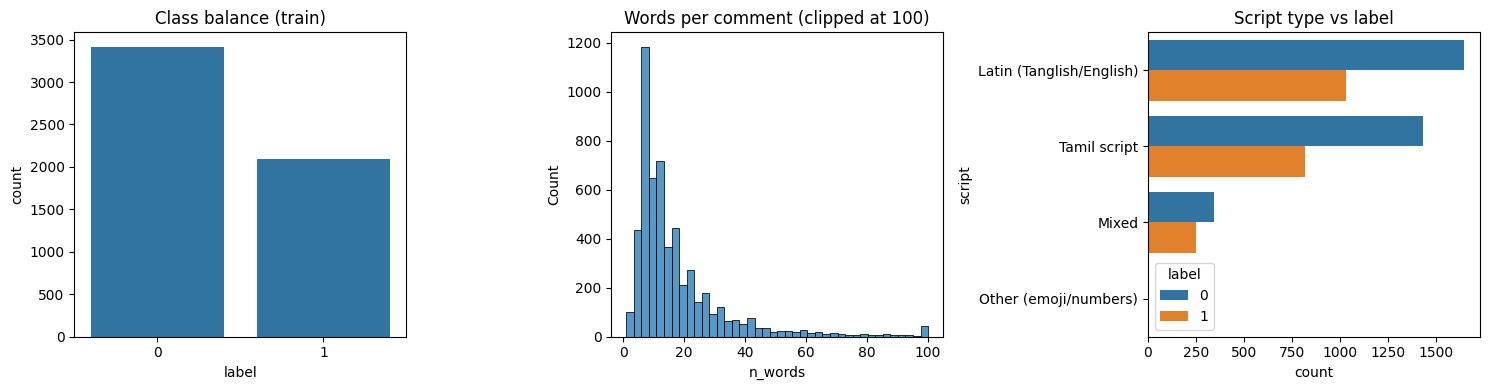

In [7]:
def script_type(t):
    tamil = len(re.findall(r"[\u0B80-\u0BFF]", t))
    latin = len(re.findall(r"[A-Za-z]", t))
    if tamil and latin: return "Mixed"
    if tamil: return "Tamil script"
    if latin: return "Latin (Tanglish/English)"
    return "Other (emoji/numbers)"

for df in (train, dev, test):
    df["n_words"] = df.text.str.split().str.len()
    df["script"]  = df.text.apply(script_type)

print("Label distribution (train):\n", train.label.value_counts(), "\n")
print("Label distribution (dev):\n", dev.label.value_counts(), "\n")
print("Script distribution (train):\n", train.script.value_counts(), "\n")
print("Label rate per script:\n", train.groupby("script").label.mean().round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="label", data=train, ax=ax[0]); ax[0].set_title("Class balance (train)")
sns.histplot(train.n_words.clip(upper=100), bins=40, ax=ax[1]); ax[1].set_title("Words per comment (clipped at 100)")
sns.countplot(y="script", hue="label", data=train, ax=ax[2]); ax[2].set_title("Script type vs label")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/eda.png", dpi=200); plt.show()

In [8]:
dups = train.text.duplicated(keep=False).sum()
conflict = (train.groupby("text").label.nunique() > 1).sum()
print(f"Duplicate rows in train: {dups}")
print(f"Texts with conflicting labels: {conflict}")
print(f"Dev texts also in train:  {dev.text.isin(train.text).sum()} / {len(dev)}")
print(f"Test texts also in train: {test.text.isin(train.text).sum()} / {len(test)}")

Duplicate rows in train: 2037
Texts with conflicting labels: 4
Dev texts also in train:  295 / 787
Test texts also in train: 557 / 1576


In [9]:
def clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", t)
    t = t.replace("\\n", " ")
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"@\S+", " ", t)
    t = re.sub(r"\b\d{1,2}:\d{2}(:\d{2})?\b", " ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = t.lower()
    return re.sub(r"\s+", " ", t).strip()

print(clean_text("@vijayakumarp7959  Unmai thaaaan 13:10 😂😂😂 https://t.co/x"))

unmai thaan 😂😂


In [10]:
def build(df):
    df = df.copy(); df["clean"] = df.text.apply(clean_text)
    return df[df.clean.str.len() > 0]

tr, dv, te = build(train), build(dev), build(test)

conf_texts = tr.groupby("clean").label.nunique()
conf_texts = conf_texts[conf_texts > 1].index
tr = tr[~tr.clean.isin(conf_texts)].drop_duplicates("clean").reset_index(drop=True)
dv = dv[~dv.clean.isin(tr.clean)].drop_duplicates("clean").reset_index(drop=True)

print("clean train:", tr.shape, " clean dev:", dv.shape)
print(tr.label.value_counts(normalize=True).round(3).to_dict(), dv.label.value_counts(normalize=True).round(3).to_dict())

clean train: (4460, 6)  clean dev: (474, 6)
{0: 0.639, 1: 0.361} {0: 0.684, 1: 0.316}


In [11]:
import torch; print("GPU available:", torch.cuda.is_available())

GPU available: True


In [12]:
# --- Part B code (needs GPU; Part A cells must have been run in the SAME session first) ---
import torch, numpy as np, pandas as pd, os, re, unicodedata
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback, set_seed)

# (re-use clean_text() from A5 and the cleaned `tr`, `dv`, `te` DataFrames from A6;
#  in Colab paste those cells first, or save them: tr.to_csv("tr_clean.csv") etc.)

class TextDS(Dataset):
    def __init__(self, texts, labels, tok, max_len=128):
        self.enc = tok(list(texts), truncation=True, max_length=max_len)  # dynamic padding later
        self.labels = None if labels is None else list(labels)
    def __len__(self): return len(self.enc["input_ids"])
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        if self.labels is not None: item["labels"] = int(self.labels[i])
        return item

def compute_metrics(eval_pred):
    logits, y = eval_pred; p = logits.argmax(-1)
    return {"accuracy": accuracy_score(y, p), "macro_f1": f1_score(y, p, average="macro")}

def run_transformer(model_name, tr, dv, te, seed=42, epochs=5, lr=2e-5, bs=16, max_len=128):
    set_seed(seed)
    is_bloom = "bloom" in model_name.lower()
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:                       # decoder models (BLOOM/GPT) may lack a pad token
        tok.pad_token = tok.eos_token
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.config.pad_token_id = tok.pad_token_id    # BLOOM classifies using the last non-pad token
    model.config.use_cache = False                  # stops decoder models returning extra cache tensors that break metrics
    use_bf16 = is_bloom and torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    use_fp16 = torch.cuda.is_available() and not is_bloom   # BLOOM + fp16 can give NaN losses; T4 has no bf16 -> fp32
    ds_tr, ds_dv = TextDS(tr.clean, tr.label, tok, max_len), TextDS(dv.clean, dv.label, tok, max_len)
    out = f"ckpt/{model_name.replace('/', '_')}_s{seed}"
    import dataclasses, math
    valid = {f.name for f in dataclasses.fields(TrainingArguments)}      # what THIS transformers version accepts
    steps_per_epoch = math.ceil(len(ds_tr) / bs)
    targs = dict(
        output_dir=out, num_train_epochs=epochs, learning_rate=lr,
        per_device_train_batch_size=bs, per_device_eval_batch_size=64,
        weight_decay=0.01, warmup_steps=int(0.1 * steps_per_epoch * epochs),   # 10% warm-up (works in all versions)
        save_strategy="epoch", load_best_model_at_end=True, metric_for_best_model="macro_f1",
        save_total_limit=1, fp16=use_fp16, bf16=use_bf16, seed=seed, report_to="none")
    targs["eval_strategy" if "eval_strategy" in valid else "evaluation_strategy"] = "epoch"
    dropped = [k for k in targs if k not in valid]
    if dropped: print("Note: this transformers version ignores:", dropped)
    args = TrainingArguments(**{k: v for k, v in targs.items() if k in valid})
    kw = dict(model=model, args=args, train_dataset=ds_tr, eval_dataset=ds_dv,
              compute_metrics=compute_metrics,
              callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    try:
        trainer = Trainer(processing_class=tok, **kw)   # transformers >= 4.46
    except TypeError:
        trainer = Trainer(tokenizer=tok, **kw)          # older versions
    trainer.train()
    dv_logits = trainer.predict(ds_dv).predictions
    te_logits = trainer.predict(TextDS(te.clean, None, tok, max_len)).predictions
    pred = dv_logits.argmax(-1)
    p, r, f, _ = precision_recall_fscore_support(dv.label, pred, average="macro", zero_division=0)
    res = dict(model=model_name, seed=seed, accuracy=accuracy_score(dv.label, pred), macro_P=p, macro_R=r,
               macro_F1=f, weighted_F1=f1_score(dv.label, pred, average="weighted"),
               hate_F1=f1_score(dv.label, pred, pos_label=1))
    return res, dv_logits, te_logits

In [13]:
# Run all transformers x 3 seeds (≈10–20 min per run on a T4). Start with 1 seed to test!
# The three models we compare (+ mBERT / XLM-R can be added back for extra baselines)
MODEL_CFG = {
    "l3cube-pune/tamil-sentence-bert-nli": dict(lr=2e-5, bs=16),   # TamilSBERT
    "google/muril-base-cased":             dict(lr=2e-5, bs=16),   # MuRIL
    "bigscience/bloom-560m":               dict(lr=1e-5, bs=8),    # BLOOM-560M (big: small batch, fp32 on T4)
    # "bert-base-multilingual-cased":      dict(lr=2e-5, bs=16),   # mBERT (optional)
    # "xlm-roberta-base":                  dict(lr=2e-5, bs=16),   # XLM-R (optional)
}
MODEL_NAMES = list(MODEL_CFG)
SEEDS = [42]            # later: [42, 7, 2024] and report mean ± std
os.makedirs("results", exist_ok=True)
all_res, dev_logits, test_logits = [], {}, {}
for m in MODEL_NAMES:
    for s in SEEDS:
        try:
            res, dl, tl = run_transformer(m, tr, dv, te, seed=s, **MODEL_CFG[m])
            all_res.append(res); dev_logits[(m, s)] = dl; test_logits[(m, s)] = tl
            pd.DataFrame(all_res).to_csv("results/transformer_results.csv", index=False)
            print(res)
        except Exception as e:
            print("FAILED", m, e)

config.json:   0%|          | 0.00/668 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/517 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,76.431133,2.920665,0.683544,0.406015
2,16.103371,1.011810,0.683544,0.406015
3,0.820944,0.828267,0.345992,0.296264


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'bigscience/bloom-560m', 'seed': 42, 'accuracy': 0.6835443037974683, 'macro_P': 0.34177215189873417, 'macro_R': 0.5, 'macro_F1': 0.40601503759398494, 'weighted_F1': 0.5550585324069668, 'hate_F1': 0.0}


In [ ]:
print("Train:", len(tr))
print("Dev:", len(dv))
print("Test:", len(te))

Train: 4460
Dev: 474
Test: 1576


In [14]:
from scipy.special import softmax
if len(dev_logits) > 1:
    avg = np.mean([softmax(v, axis=1) for v in dev_logits.values()], axis=0)
    print("Ensemble macro-F1:", f1_score(dv.label, avg.argmax(1), average="macro"))

Ensemble macro-F1: 0.40601503759398494


In [1]:
!ls -lh /content/*.ipynb

ls: cannot access '/content/*.ipynb': No such file or directory
